In [24]:
from pathlib import Path
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import pathlib
import pandas as pd
import re
from sklearn.model_selection import train_test_split
import torch.optim as optim
import time
import sys
#sys.path.append("/Users/deborahfu/eecs281/eecs545/Project/neurovfm")

from mil import pad_ragged, AggregateThenClassify, ClassifyThenAggregate

In [25]:
path_openbhb = pathlib.Path('/Users/racheliritani/Desktop/neurovfm/output/openBHB_train_emmbeddings')
adni_folder_path = '/Users/racheliritani/Desktop/neurovfm/output/ADNI_train_embeddings'
path_adni = pathlib.Path(adni_folder_path)

# Load both metadata files
subject_meta = pd.read_csv('/Users/racheliritani/Desktop/neurovfm/output/openBHB_train_emmbeddings/for_training_participants.tsv', sep='\t')
subject_meta['participant_id'] = subject_meta['participant_id'].astype(str)

adni_meta_path = os.path.join(adni_folder_path, '00_adni_metadata.tsv')
adni_meta = pd.read_csv(adni_meta_path, sep='\t')
adni_meta['participant_id'] = adni_meta['source_file'].str.extract(r'(.+)_encoder_embeddings\.pt')
adni_meta['participant_id'] = adni_meta['participant_id'].astype(str)

# Load diagnosis labels for ADNI
diagnosis_labels = pd.read_csv('/Users/racheliritani/Desktop/neurovfm/abmil_results_20260416_232043/00_diagonsis_label.tsv')
diagnosis_labels['PTID'] = diagnosis_labels['PTID'].astype(str)

# Patterns for each dataset
openbhb_pattern = re.compile(r'sub-([^_]+)_encoder_embeddings\.pt')
adni_pattern = re.compile(r'(.+)_encoder_embeddings\.pt')

# Separate lists for each dataset
openbhb_data_list = []
adni_data_list = []

# Load from OpenBHB folder (all labeled as 'CN' - cognitively normal)
for file in path_openbhb.glob('*.pt'):
    if openbhb_pattern.match(file.name):
        match = openbhb_pattern.search(file.name)
        subj_id = match.group(1)
        emb_tensor = torch.load(file, map_location='cpu')
        openbhb_data_list.append({
            'subject id': subj_id,
            'embedding': emb_tensor.detach().cpu(),
            'diagnosis': 'CN'  # All OpenBHB subjects are cognitively normal
        })

# Load from ADNI folder with actual diagnosis labels
for file in path_adni.glob('*.pt'):
    if adni_pattern.match(file.name):
        match = adni_pattern.search(file.name)
        subj_id = match.group(1)
        emb_tensor = torch.load(file, map_location='cpu')

        # Find diagnosis for this subject
        diagnosis_row = diagnosis_labels[diagnosis_labels['PTID'] == subj_id]
        if len(diagnosis_row) > 0:
            diagnosis = diagnosis_row['DIAGNOSIS'].iloc[0]
        else:
            diagnosis = 'CN'  # Default to CN if not found

        adni_data_list.append({
            'subject id': subj_id,
            'embedding': emb_tensor.detach().cpu(),
            'diagnosis': diagnosis
        })

# Create DataFrames
openbhb_emb_df = pd.DataFrame(openbhb_data_list)
adni_emb_df = pd.DataFrame(adni_data_list)

# Merge with metadata
openbhb_age_embedding_df = pd.merge(openbhb_emb_df, subject_meta, left_on='subject id', right_on='participant_id', how='inner')
adni_age_embedding_df = pd.merge(adni_emb_df, adni_meta, left_on='subject id', right_on='participant_id', how='inner')

# Combine datasets
combined_df = pd.concat([openbhb_age_embedding_df, adni_age_embedding_df], ignore_index=True)

# Create label mapping
label_to_idx = {'CN': 0, 'MCI': 1, 'Dementia': 2}
idx_to_label = {v: k for k, v in label_to_idx.items()}

# Clean diagnosis labels and add numeric labels
combined_df['diagnosis'] = combined_df['diagnosis'].astype(str).replace('nan', None)
combined_df['diagnosis'] = combined_df['diagnosis'].fillna('CN')
combined_df['diagnosis'] = combined_df['diagnosis'].replace({'CN': 'CN', 'MCI': 'MCI', 'Dementia': 'Dementia'})

invalid_diagnoses = combined_df.loc[~combined_df['diagnosis'].isin(label_to_idx), 'diagnosis'].unique()
if len(invalid_diagnoses) > 0:
    print("Warning: found unexpected diagnosis labels and setting them to 'CN':", invalid_diagnoses)
    combined_df.loc[~combined_df['diagnosis'].isin(label_to_idx), 'diagnosis'] = 'CN'

combined_df['label'] = combined_df['diagnosis'].map(label_to_idx)
combined_df = combined_df.dropna(subset=['label'])

print("Label distribution:")
print(combined_df['diagnosis'].value_counts())
print(f"\nTotal samples: {len(combined_df)}")

train_df, eval_df = train_test_split(
    combined_df,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)

Label distribution:
diagnosis
CN    10
Name: count, dtype: int64

Total samples: 10


In [26]:
import numpy as np

# Define dataset and collate function
class BagDataset(Dataset):
    def __init__(self, df):
        self.embeddings = list(df['embedding'])
        self.labels = torch.tensor(df['label'].values, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]

def collate_bags(batch):
    emb_list, labels = zip(*batch)
    lengths = [x.shape[0] for x in emb_list]
    cu_seqlens = torch.tensor([0] + np.cumsum(lengths).tolist(), dtype=torch.long)
    emb_cat = torch.cat(emb_list, dim=0)
    labels = torch.stack(labels)
    return emb_cat, cu_seqlens, labels

# Create datasets
train_dataset = BagDataset(train_df)
eval_dataset = BagDataset(eval_df)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_bags,
)

eval_loader = DataLoader(
    eval_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_bags,
)

In [27]:
class ABMILClassification(nn.Module):
    def __init__(self, dim, hidden_dim=None, num_classes=3):
        super().__init__()
        self.pooling = AggregateThenClassify(dim=dim, hidden_dim=hidden_dim, W_out=1)
        self.classifier = nn.Linear(dim, num_classes)

    def forward(self, emb_list, seq_position, return_attn_weights=False):
        bags, attn_weights = self.pooling(emb_list, seq_position, return_attn_probs=True)
        logits = self.classifier(bags)

        if return_attn_weights:
            return logits, attn_weights
        else:
            return logits

In [28]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ABMILClassification(dim=768, hidden_dim=256, num_classes=3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
print(f'Model initialized on {device}')
print(f'Classes: {list(label_to_idx.keys())}')

Model initialized on cpu
Classes: ['CN', 'MCI', 'Dementia']


In [29]:
def train_epoch(model, data_loader, optimizer, criterion, device, epochs=100, return_attn_weights=False):
    train_losses = []
    eval_losses = []
    train_accuracies = []
    eval_accuracies = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        correct = 0
        total = 0

        for emb_cat, cu_seqlens, labels in train_loader:
            emb_cat = emb_cat.to(device, dtype=torch.float32)
            cu_seqlens = cu_seqlens.to(device, dtype=torch.long)
            labels = labels.to(device, dtype=torch.long)

            optimizer.zero_grad()
            outputs = model(emb_cat, cu_seqlens)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = epoch_loss / len(train_loader)
        train_accuracy = 100 * correct / total
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        # Validation
        model.eval()
        eval_loss = 0.0
        correct = 0
        total = 0
        all_labels = []
        all_outputs = []
        all_attn_weights = [] if return_attn_weights else None
        all_cu_seqlens = [] if return_attn_weights else None

        with torch.no_grad():
            for emb_cat, cu_seqlens, labels in eval_loader:
                emb_cat = emb_cat.to(device, dtype=torch.float32)
                cu_seqlens = cu_seqlens.to(device, dtype=torch.long)
                labels = labels.to(device, dtype=torch.long)

                if return_attn_weights:
                    outputs, attn_weights = model(emb_cat, cu_seqlens, return_attn_weights=True)
                    all_attn_weights.append(attn_weights.cpu())
                    all_cu_seqlens.append(cu_seqlens.cpu())
                else:
                    outputs = model(emb_cat, cu_seqlens)

                loss = criterion(outputs, labels)
                eval_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

                all_labels.append(labels.cpu())
                all_outputs.append(outputs.cpu())

        eval_loss = eval_loss / len(eval_loader)
        eval_accuracy = 100 * correct / total
        eval_losses.append(eval_loss)
        eval_accuracies.append(eval_accuracy)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f}, Acc: {train_accuracy:.2f}% | Val Loss: {eval_loss:.4f}, Acc: {eval_accuracy:.2f}%")

    all_labels = torch.cat(all_labels)
    all_outputs = torch.cat(all_outputs)

    # Process attention weights to create per-subject maps
    if return_attn_weights:
        all_attn_weights = torch.cat(all_attn_weights)  # [total_tokens, 1]

        # Create per-subject attention weight maps
        subject_attention_maps = []
        token_offset = 0

        for batch_cu_seqlens in all_cu_seqlens:
            # batch_cu_seqlens includes the starting 0, so we iterate through pairs
            for i in range(len(batch_cu_seqlens) - 1):
                start_idx = batch_cu_seqlens[i].item()
                end_idx = batch_cu_seqlens[i + 1].item()
                seq_length = end_idx - start_idx

                # Extract attention weights for this subject
                subject_attn = all_attn_weights[token_offset + start_idx:token_offset + end_idx]
                subject_attention_maps.append(subject_attn.squeeze(-1))  # Remove last dim

            token_offset += batch_cu_seqlens[-1].item()

        all_attn_weights = subject_attention_maps  # Now a list of tensors, one per subject

    return train_losses, eval_losses, train_accuracies, eval_accuracies, all_labels, all_outputs, all_attn_weights

In [30]:
start_time = time.time()
train_losses, val_losses, train_accuracies, val_accuracies, labels, outputs, attn_weights = train_epoch(
    model, train_loader, optimizer, criterion, device, epochs=100, return_attn_weights=True
)
end_time = time.time()
total_time = end_time - start_time
print(f"Training Complete!")
print(f"Total time: {int(total_time // 60)}m {int(total_time % 60)}s")

Epoch [10/100] | Train Loss: 0.0016, Acc: 100.00% | Val Loss: 0.0014, Acc: 100.00%
Epoch [20/100] | Train Loss: 0.0003, Acc: 100.00% | Val Loss: 0.0003, Acc: 100.00%
Epoch [30/100] | Train Loss: 0.0002, Acc: 100.00% | Val Loss: 0.0002, Acc: 100.00%
Epoch [40/100] | Train Loss: 0.0002, Acc: 100.00% | Val Loss: 0.0002, Acc: 100.00%
Epoch [50/100] | Train Loss: 0.0002, Acc: 100.00% | Val Loss: 0.0002, Acc: 100.00%
Epoch [60/100] | Train Loss: 0.0002, Acc: 100.00% | Val Loss: 0.0002, Acc: 100.00%
Epoch [70/100] | Train Loss: 0.0002, Acc: 100.00% | Val Loss: 0.0002, Acc: 100.00%
Epoch [80/100] | Train Loss: 0.0001, Acc: 100.00% | Val Loss: 0.0002, Acc: 100.00%
Epoch [90/100] | Train Loss: 0.0001, Acc: 100.00% | Val Loss: 0.0002, Acc: 100.00%
Epoch [100/100] | Train Loss: 0.0001, Acc: 100.00% | Val Loss: 0.0001, Acc: 100.00%
Training Complete!
Total time: 0m 9s


CLASSIFICATION MODEL EVALUATION METRICS
Overall Accuracy: 1.0000 (100.00%)
F1 Score (Macro): 1.0000
F1 Score (Weighted): 1.0000

Detailed Classification Report:
              precision    recall  f1-score   support

          CN       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2


ATTENTION WEIGHTS ANALYSIS
Attention weights shape: torch.Size([1575])
Attention weights range: [0.0000, 0.0093]
Attention weights mean: 0.0013
Attention weights std: 0.0023


/Users/racheliritani/opt/anaconda3/envs/mm-vae/lib/python3.11/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


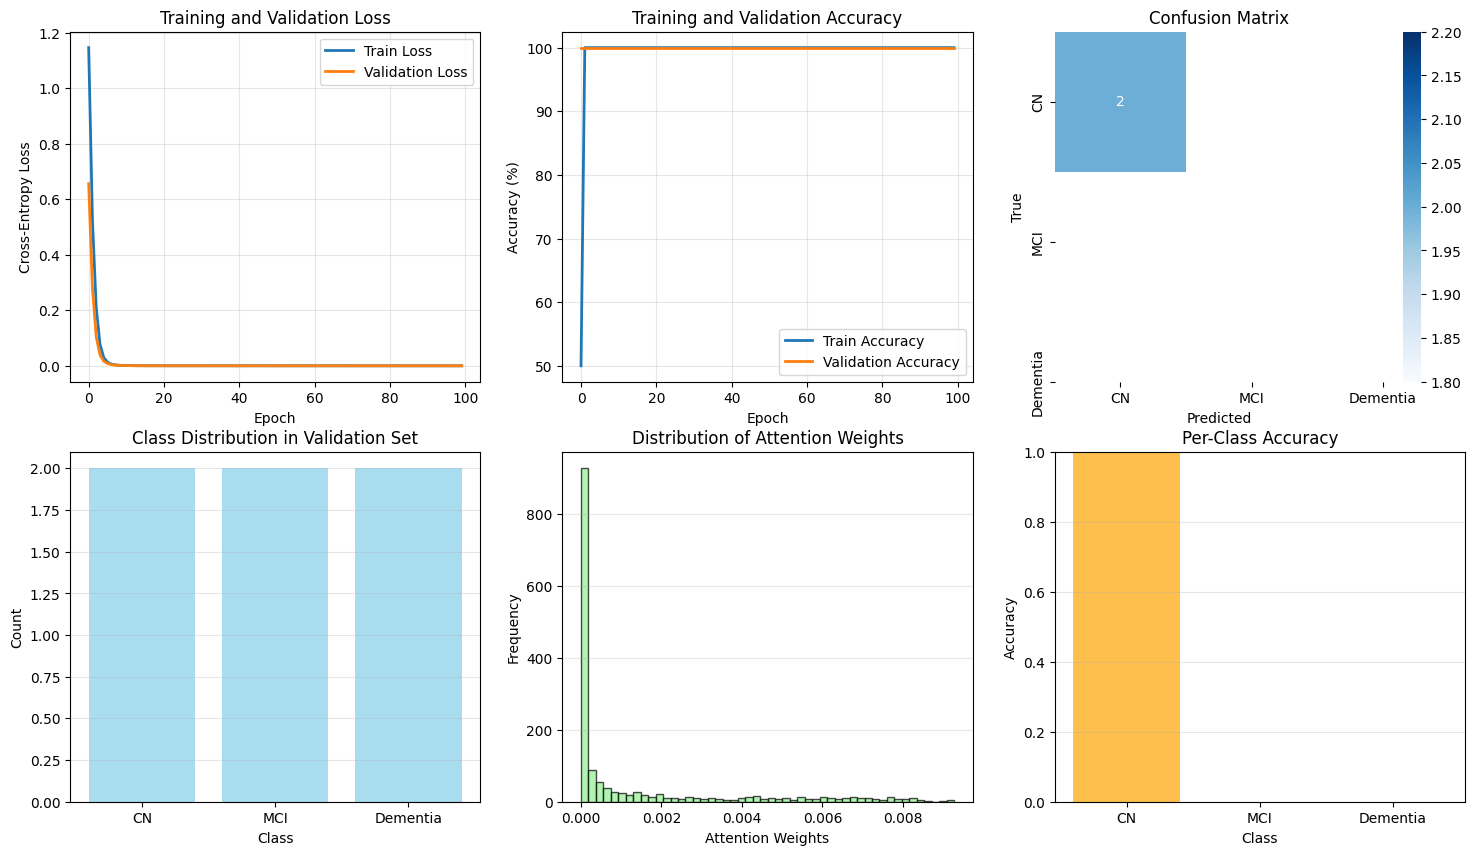

<Figure size 640x480 with 0 Axes>

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import numpy as np

# Get predictions
_, predicted = torch.max(outputs, 1)
predicted = predicted.numpy()
true_labels = labels.numpy()

# Calculate metrics
accuracy = accuracy_score(true_labels, predicted)
f1_macro = f1_score(true_labels, predicted, average='macro')
f1_weighted = f1_score(true_labels, predicted, average='weighted')

print("=" * 60)
print("CLASSIFICATION MODEL EVALUATION METRICS")
print("=" * 60)
print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"F1 Score (Macro): {f1_macro:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")
print("=" * 60)

print("\nDetailed Classification Report:")
unique_labels = np.unique(np.concatenate([true_labels, predicted]))
label_names = [idx_to_label[int(label)] for label in unique_labels]
print(classification_report(true_labels, predicted, labels=unique_labels, target_names=label_names))

# Attention weights analysis
if attn_weights is not None:
    all_attn = torch.cat(attn_weights)
    print("\nATTENTION WEIGHTS ANALYSIS")
    print("=" * 50)
    print(f"Attention weights shape: {all_attn.shape}")
    print(f"Attention weights range: [{all_attn.min().item():.4f}, {all_attn.max().item():.4f}]")
    print(f"Attention weights mean: {all_attn.mean().item():.4f}")
    print(f"Attention weights std: {all_attn.std().item():.4f}")
    print("=" * 50)

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Training and validation loss curves
axes[0, 0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0, 0].plot(val_losses, label='Validation Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Cross-Entropy Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Training and validation accuracy curves
axes[0, 1].plot(train_accuracies, label='Train Accuracy', linewidth=2)
axes[0, 1].plot(val_accuracies, label='Validation Accuracy', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Confusion Matrix
cm = confusion_matrix(true_labels, predicted)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(label_to_idx.keys()),
            yticklabels=list(label_to_idx.keys()), ax=axes[0, 2])
axes[0, 2].set_xlabel('Predicted')
axes[0, 2].set_ylabel('True')
axes[0, 2].set_title('Confusion Matrix')

# 4. Class distribution
class_counts = np.bincount(true_labels)
axes[1, 0].bar(list(label_to_idx.keys()), class_counts, alpha=0.7, color='skyblue')
axes[1, 0].set_xlabel('Class')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Class Distribution in Validation Set')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 5. Attention weights distribution (if available)
if attn_weights is not None:
    all_attn = torch.cat(attn_weights).numpy()
    axes[1, 1].hist(all_attn, bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
    axes[1, 1].set_xlabel('Attention Weights')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Distribution of Attention Weights')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
else:
    axes[1, 1].text(0.5, 0.5, 'No Attention Weights\nAvailable',
                    ha='center', va='center', transform=axes[1, 1].transAxes,
                    fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))
    axes[1, 1].set_title('Attention Weights Distribution')
    axes[1, 1].set_xlabel('Attention Weights')
    axes[1, 1].set_ylabel('Frequency')

# 6. Per-class accuracy
class_accuracies = []
for i, class_name in enumerate(list(label_to_idx.keys())):
    class_mask = (true_labels == i)
    if np.sum(class_mask) > 0:
        class_acc = np.mean(predicted[class_mask] == i)
        class_accuracies.append(class_acc)
    else:
        class_accuracies.append(0.0)

axes[1, 2].bar(list(label_to_idx.keys()), class_accuracies, alpha=0.7, color='orange')
axes[1, 2].set_xlabel('Class')
axes[1, 2].set_ylabel('Accuracy')
axes[1, 2].set_title('Per-Class Accuracy')
axes[1, 2].set_ylim(0, 1)
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.show()
plt.tight_layout()

In [32]:
import os
from datetime import datetime

# Create timestamped output directory
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = f"/Users/racheliritani/Desktop/neurovfm/abmil_classification_results_{timestamp}"
os.makedirs(output_dir, exist_ok=True)

print(f"Saving results to: {output_dir}")

# 1. Save the evaluation figure
fig_path = os.path.join(output_dir, "evaluation_metrics.png")
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"✓ Figure saved: {fig_path}")

# 2. Save metrics to text file
metrics_path = os.path.join(output_dir, "metrics_summary.txt")
with open(metrics_path, 'w') as f:
    f.write("=" * 60 + "\n")
    f.write("ABMIL CLASSIFICATION MODEL - EVALUATION METRICS\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")

    f.write("DATASET INFORMATION:\n")
    f.write(f"  Train set size: {len(train_df)}\n")
    f.write(f"  Eval set size: {len(eval_df)}\n")
    f.write(f"  Total samples: {len(combined_df)}\n")
    f.write(f"  Train-Eval split: 80-20 (stratified)\n\n")

    f.write("CLASS INFORMATION:\n")
    for class_name, idx in label_to_idx.items():
        count = (combined_df['diagnosis'] == class_name).sum()
        f.write(f"  {class_name} (label {idx}): {count} samples\n")
    f.write("\n")

    f.write("MODEL CONFIGURATION:\n")
    f.write(f"  Input dimension: 768\n")
    f.write(f"  Hidden dimension: 256\n")
    f.write(f"  Number of classes: 3\n")
    f.write(f"  Pooling method: AggregateThenClassify\n")
    f.write(f"  Batch size: 4\n")
    f.write(f"  Epochs: 100\n")
    f.write(f"  Learning rate: 0.001\n")
    f.write(f"  Optimizer: Adam\n")
    f.write(f"  Loss function: Cross-Entropy\n\n")

    f.write("EVALUATION METRICS:\n")
    f.write(f"  Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)\n")
    f.write(f"  F1 Score (Macro): {f1_macro:.4f}\n")
    f.write(f"  F1 Score (Weighted): {f1_weighted:.4f}\n\n")

    f.write("CLASSIFICATION REPORT:\n")
    unique_labels = np.unique(np.concatenate([true_labels, predicted]))
    unique_label_names = [idx_to_label[int(label)] for label in unique_labels]
    report_lines = classification_report(true_labels, predicted, labels=unique_labels, target_names=unique_label_names).split('\n')
    for line in report_lines:
        f.write(f"  {line}\n")

    if attn_weights is not None:
        overall_attn = torch.cat(attn_weights)
        f.write("\nATTENTION WEIGHTS STATISTICS:\n")
        f.write(f"  Attention weights shape: {overall_attn.shape}\n")
        f.write(f"  Attention weights range: [{overall_attn.min().item():.4f}, {overall_attn.max().item():.4f}]\n")
        f.write(f"  Attention weights mean: {overall_attn.mean().item():.4f}\n")
        f.write(f"  Attention weights std: {overall_attn.std().item():.4f}\n\n")

    f.write("TRAINING CURVES:\n")
    f.write(f"  Final training loss:   {train_losses[-1]:.4f}\n")
    f.write(f"  Final validation loss: {val_losses[-1]:.4f}\n")
    f.write(f"  Final training accuracy:   {train_accuracies[-1]:.2f}%\n")
    f.write(f"  Final validation accuracy: {val_accuracies[-1]:.2f}%\n")
    f.write("=" * 60 + "\n")

print(f"✓ Metrics saved: {metrics_path}")

# 3. Save detailed predictions to CSV
predictions_path = os.path.join(output_dir, "predictions.csv")
predictions_df = pd.DataFrame({
    'true_label': [idx_to_label[label] for label in true_labels],
    'predicted_label': [idx_to_label[pred] for pred in predicted],
    'correct': (true_labels == predicted).astype(int)
})
predictions_df.to_csv(predictions_path, index=False)
print(f"✓ Predictions saved: {predictions_path}")

# 4. Save attention weights to CSV (if available)
if attn_weights is not None:
    overall_attn = torch.cat(attn_weights)
    attn_weights_path = os.path.join(output_dir, "attention_weights.csv")
    attn_df = pd.DataFrame({
        'attention_weight': overall_attn.numpy()
    })
    attn_df.to_csv(attn_weights_path, index=False)
    print(f"✓ Attention weights saved: {attn_weights_path}")

    # Save individual subject attention maps as CSV only
    attn_maps_dir = os.path.join(output_dir, "attention_maps")
    os.makedirs(attn_maps_dir, exist_ok=True)
    subject_ids = eval_df['subject id'].tolist()

    for subject_id, subject_attn in zip(subject_ids, attn_weights):
        subject_attn_path = os.path.join(attn_maps_dir, f"subject_{subject_id}_attention.csv")
        subject_df = pd.DataFrame({
            'token_index': range(len(subject_attn)),
            'attention_weight': subject_attn.numpy()
        })
        subject_df.to_csv(subject_attn_path, index=False)

    print(f"✓ Individual attention maps saved: {attn_maps_dir}")

# 5. Save training curves to CSV
loss_path = os.path.join(output_dir, "training_curves.csv")
curves_df = pd.DataFrame({
    'epoch': range(1, len(train_losses) + 1),
    'train_loss': train_losses,
    'val_loss': val_losses,
    'train_accuracy': train_accuracies,
    'val_accuracy': val_accuracies
})
curves_df.to_csv(loss_path, index=False)
print(f"✓ Training curves saved: {loss_path}")

print(f"\n✓ All results saved to: {os.path.abspath(output_dir)}")

Saving results to: /Users/racheliritani/Desktop/neurovfm/abmil_classification_results_20260417_174206
✓ Figure saved: /Users/racheliritani/Desktop/neurovfm/abmil_classification_results_20260417_174206/evaluation_metrics.png
✓ Metrics saved: /Users/racheliritani/Desktop/neurovfm/abmil_classification_results_20260417_174206/metrics_summary.txt
✓ Predictions saved: /Users/racheliritani/Desktop/neurovfm/abmil_classification_results_20260417_174206/predictions.csv
✓ Attention weights saved: /Users/racheliritani/Desktop/neurovfm/abmil_classification_results_20260417_174206/attention_weights.csv
✓ Individual attention maps saved: /Users/racheliritani/Desktop/neurovfm/abmil_classification_results_20260417_174206/attention_maps
✓ Training curves saved: /Users/racheliritani/Desktop/neurovfm/abmil_classification_results_20260417_174206/training_curves.csv

✓ All results saved to: /Users/racheliritani/Desktop/neurovfm/abmil_classification_results_20260417_174206
